In [1]:
import numpy as np, cv2
import matplotlib.pyplot as plt
from tools.tools import *
import imageio.v3 as iio
from IPython.display import HTML

%load_ext autoreload
%autoreload 2

REAL_BAG_PATH = "/root/stonefish_ros2_ws/sintef_dataset/2024-08-22_14-29-05_video.bag"
SIM_BAG_PATH = "/root/stonefish_ros2_ws/recorded_data/simulation/rosbag2_2025_11_12-10_16_52"

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
print_bag_topics(REAL_BAG_PATH)
camera = get_compressed_color_image(bag=REAL_BAG_PATH, topic="/image/compressed_image/data")

Topics and message types:
/image/compressed_image/camera_info            sensor_msgs/msg/CameraInfo
/image/compressed_image/data                   sensor_msgs/msg/CompressedImage
/sensor/sonoptix_echo/image                    sensors/msg/SonoptixECHO


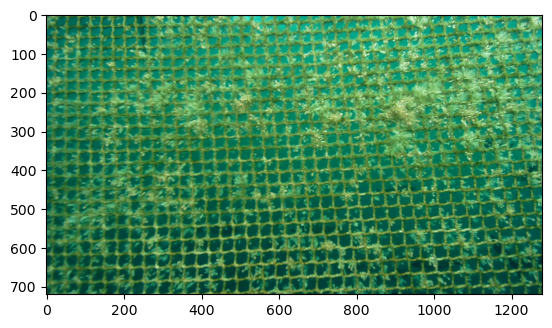

In [7]:
plt.imshow(get_image_nearest_time(camera, 20))

In [3]:
sim_camera = get_color_image_data(bag=SIM_BAG_PATH, topic="/center_camera/image_color")

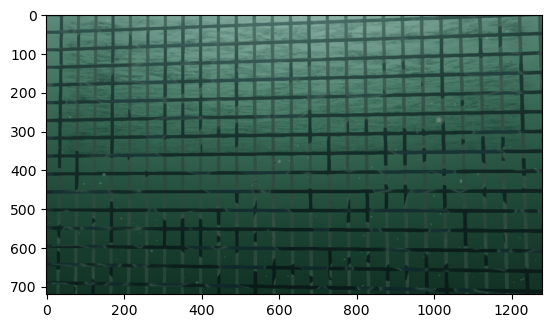

In [6]:
plt.imshow(get_image_nearest_time(sim_camera, 20))

# Stereo Camera

In [8]:
cam_left = get_color_image_data(bag=SIM_BAG_PATH, topic="/left_camera/image_color")
cam_right = get_color_image_data(bag=SIM_BAG_PATH, topic="/right_camera/image_color")

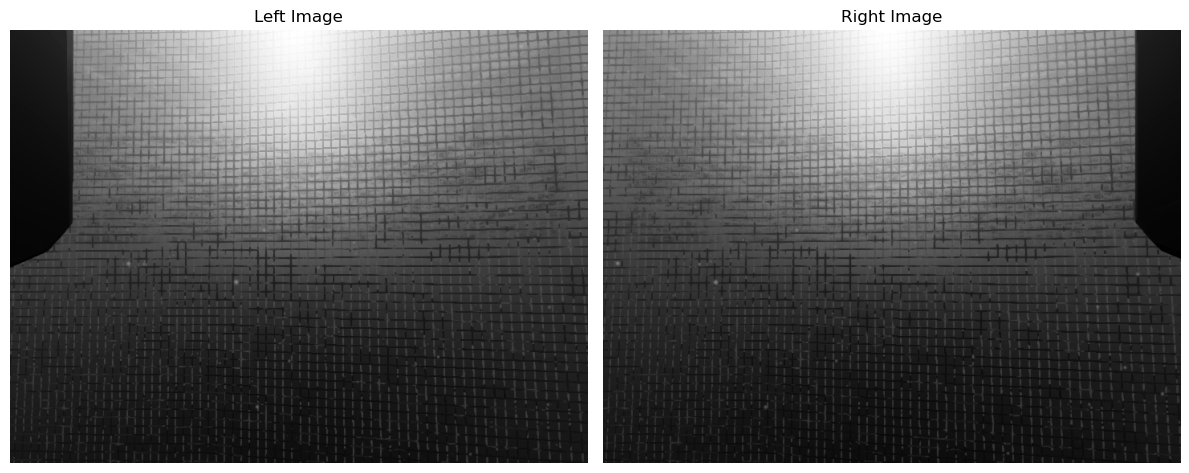

In [9]:
time = 20

left_image = get_image_nearest_time(cam_left, time)
right_image = get_image_nearest_time(cam_right, time)


left_image = cv2.cvtColor(left_image, cv2.COLOR_BGR2GRAY)
right_image = cv2.cvtColor(right_image, cv2.COLOR_BGR2GRAY)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(left_image, cmap="gray")
axes[0].set_title("Left Image")
axes[0].axis("off")

axes[1].imshow(right_image, cmap="gray")
axes[1].set_title("Right Image")
axes[1].axis("off")

plt.tight_layout()

Comment: No lense distortion

# Video

In [9]:
frames = np.array(camera["image"]).astype(np.uint8)
iio.imwrite("videos/camera.gif", frames, format="GIF", fps=15)
HTML('<a href="videos/camera.gif" target="_blank">Open GIF</a>')

frames = np.array(sim_camera["image"]).astype(np.uint8)
iio.imwrite("videos/sim_camera.gif", frames, format="GIF", fps=15)
HTML('<a href="videos/sim_camera.gif" target="_blank">Open GIF</a>')